# NCCU Deep Learning: Fundamental and Applications
## Programming Assignment #1

Welcome to your first programming assignment. In this exercise, you will learn how to train a multilayer perceptron using the CIFAR-100 dataset.

An example is provided below on how to train CIFAR-100 dataset, which contains 100 classes of colored images representing a wide variety of objects such as animals, vehicles, and everyday items.  The goal is to build a neural network that can correctly recognize the objectives.  Please run through the notebook to get yourself familiarized with the basic PyTorch framework for training a neural network.

***Your assignment:***


*   Clone the notebook
*   Follow the example below, train the network using CIFAR-100 dataset, observe the performance for loss and accuracy.(Note: Some parts of the code are intentionally hidden for your assignment.)
*   ***The last text block provides the to-do list that you need to complete***, follow the description and report on your findings.


# Your Deep Learning Journey: A Practical Guide

We'll process the dataset, build our model, and then train our model. Afterwards, we'll do a short dive into what the model has actually learned.

To ensure we get reproducible results, we set the random seed for Python, NumPy, and PyTorch. This helps ensure consistent behavior across runs by controlling randomness in data shuffling, weight initialization, and other stochastic processes.

(note: We recommend you to use google colab to do the assignment.)

In [109]:
import random
import numpy as np
import torch

SEED = 9999
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

print("Random sample (Python):", random.random())
print("Random sample (NumPy):", np.random.rand())
print("Random sample (PyTorch):", torch.rand(1).item())

Random sample (Python): 0.8347577610922152
Random sample (NumPy): 0.8233890742543671
Random sample (PyTorch): 0.7876027822494507


## **Data**
The first step is to load the CIFAR-100 dataset. This will automatically download the training set and save it in a folder named .data, creating the folder if it doesn't exist. We use torchvision.datasets to load the dataset and torchvision.transforms to apply preprocessing.

For now, we apply a simple transform:

ToTensor(): Converts each image from a PIL format to a PyTorch tensor and scales pixel values to the 0,1 range.

In [110]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import Subset
from torch.utils.data import random_split

import numpy as np

transform = transforms.Compose([
    transforms.ToTensor(),
])

# Selected classes, we select 10 classes to train faster in the assignment.
selected_classes = list(range(10))  # Classes 0~9

# Load the full original dataset
trainset_full = datasets.CIFAR100(
    root='./data', train=True, download=True, transform=transform)

# Find indices that match the selected classes
train_indices = [i for i, label in enumerate(trainset_full.targets) if label in selected_classes]

# Randomly select a subset (here is 2000 images)
np.random.seed(0)  # Fix seed for reproducibility
train_indices_subset = np.random.choice(train_indices, size=2000, replace=False)

# Create a new training subset
small_trainset = Subset(trainset_full, train_indices_subset)

# Apply the same filtering for the test set (keep all samples from selected classes)
testset_full = datasets.CIFAR100(
    root='./data', train=False, download=True, transform=transform)

test_indices = [i for i, label in enumerate(testset_full.targets) if label in selected_classes]
small_testset = Subset(testset_full, test_indices)

# total size of small_trainset
k = 10
train_size = int(((k-1)/k) * len(small_trainset))   # 90% for training
val_size   = len(small_trainset) - train_size # remaining 10% for validation

# random split
train_subset, val_subset = random_split(small_trainset, [train_size, val_size])


print(f'Number of training images (10 classes): {len(train_subset)}')
print(f'Number of validation images (10 classes): {len(val_subset)}')
print(f'Number of testing images (10 classes): {len(small_testset)}')

Number of training images (10 classes): 1800
Number of validation images (10 classes): 200
Number of testing images (10 classes): 1000


We can take a look at some images from our dataset to better understand what we’re working with.  
The `plot_images` function below displays a batch of images in a nearly square grid using Matplotlib.

**Matplotlib** is a widely used Python library for creating static, animated, and interactive visualizations.  
Here, we use it to plot image tensors by first converting them from `(C, H, W)` to `(H, W, C)` format for proper rendering.  
Pixel values are clipped to the range [0, 1] to ensure they display correctly, especially if normalization was applied.

If both `labels` and `classes` are provided, the corresponding class name will be shown as the title above each image.


In [111]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_images(images, labels=None, classes=None):
    n_images = len(images)
    rows = int(np.sqrt(n_images))
    cols = int(np.ceil(n_images / rows))

    fig = plt.figure(figsize=(cols , rows))
    for i in range(n_images):
        ax = fig.add_subplot(rows, cols, i + 1)

        # tensor shape: (C, H, W) → (H, W, C)
        img = images[i].permute(1, 2, 0).cpu().numpy()

        # unnormalize if needed
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.axis('off')

        if labels is not None and classes is not None:
            ax.set_title(classes[labels[i]])

    plt.tight_layout()
    plt.show()

# **Visualizing the Data**

Let's load and visualize 16 images from our dataset. These images will have been processed through our defined transforms—such as normalization and tensor conversion.

It's important to visualize the data **after** applying transforms to make sure they still make sense. For instance, in classification tasks involving natural images like CIFAR-100, simple transformations like normalization or cropping are usually safe. However, excessive augmentation (e.g., heavy rotation or color jitter) might distort the image and confuse the model if not properly handled.

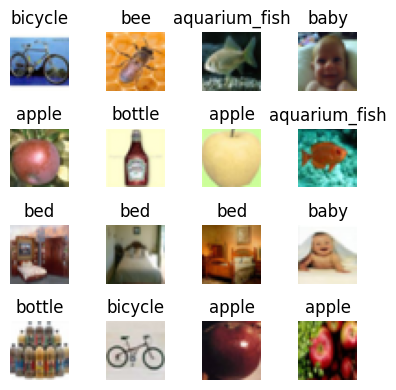

In [112]:
images = [small_trainset[i][0] for i in range(16)]
labels = [small_trainset[i][1] for i in range(16)]
classes = trainset_full.classes

plot_images(images, labels, classes)

Next, we'll define a `DataLoader` for training and testing sets. We can iterate over these, and they will yield batches of images and labels which we can use to train our model.

We only need to shuffle our training set as it will be used for stochastic gradient descent, and we want each batch to be different between epochs. As we aren't using the validation or test sets to update our model parameters, they do not need to be shuffled.

Ideally, we want to use the biggest batch size that we can. The 64 here is relatively small and can be increased if our hardware can handle it.


In [113]:
import torch.utils.data as data

BATCH_SIZE = 8

# small_trainset

train_iterator = data.DataLoader(train_subset, shuffle=True, batch_size=BATCH_SIZE)
val_iterator   = data.DataLoader(val_subset, batch_size=BATCH_SIZE)
test_iterator  = data.DataLoader(small_testset, batch_size=BATCH_SIZE)

images, labels = next(iter(train_iterator))

print(f"[INFO] Shape of one batch of images: {images.shape}")
print(f"[INFO] Shape of one batch of labels: {labels.shape}")

[INFO] Shape of one batch of images: torch.Size([8, 3, 32, 32])
[INFO] Shape of one batch of labels: torch.Size([8])


# **Defining the Model**

 Our model will be a neural network, specifically a multilayer perceptron (MLP) with two hidden layers. The image below shows the archicture of the model.(In the image, we take MNIST to be example.)

![](https://github.com/andywang947/Common/blob/main/10.png?raw=1)


Specifically, we first flatten our 3×32×32 (3 color channels, 32 pixels height and width) image into a 3072-element vector, also called 3072 features. We flatten our input, as MLPs cannot handle two- or three-dimensional data directly. Next, the 3072-dimensional input is passed through the first hidden layer, which transforms it into 250 dimensions. Then, it passes through a second hidden layer, which reduces it to 100 dimensions. Finally, an output layer transforms it into a 100-dimensional vector. The output dimension should match the number of classes in your dataset. Since CIFAR-100 contains 100 classes, we set the output size to 100.

The transformation between 3072 to 250, 250 to 100 and 100 to 10 dimensions are done by `Linear` layers. These are also known as fully connected or affine layers. In these layers, every element in one layer is connected to every element in the next. We can think of these elements as *neurons*, as this architecture is inspired by how the human brain is made of millions of interconnected nodes, also called neurons.

Each connection between a neuron in one layer and a neuron in the next has a *weight* associated with it. The input to one neuron is the sum of the weighted values of all neurons in the previous layer connected to it, plus a weighted bias term, where the bias value is always 1. The neuron then applies an *activation function* to this weighted sum. This activation function is a non-linear function that allows the neural network to learn non-linear functions between inputs and outputs.

We define our MLP below, which consists of three linear layers. We first take the input batch of images and flatten them, so they can be passed into the linear layers. We then pass them through the first linear layer, `input_fc`, which calculates the weighted sum of the inputs, and then apply the *ReLU* (rectified linear unit) activation function elementwise. This result is then passed through another linear layer, `hidden_fc`, again applying the same activation function elementwise. Finally, we pass this through the final linear layer, `output_fc`. We return not only the output but also the second hidden layer as we will do some analysis on it later.

The ReLU activation function is a popular non-linear function that is simply $max(0, x)$, where $x$ is the weighted sum of the inputs to that neuron. Other activation functions used are hyperbolic tan (tanh) and sigmoid function, however ReLU is the most commonly used.

![](https://github.com/bentrevett/pytorch-image-classification/blob/master/assets/relu.png?raw=1)


One thing to note is that we do not use an activation function on the input directly or on the output. You should never use activation functions directly on the input, i.e. `F.relu(x)`. PyTorch combines activation functions to be applied on the output with the functions which calculate the *loss*, also known as *error* or *cost*, of a neural network. This is done for numerical stability.

In [114]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.input_fc = nn.Linear(input_dim, 250)
        self.hidden_fc = nn.Linear(250, 100)
        self.output_fc = nn.Linear(100, output_dim)

    def forward(self, input):
        batch_size = input.shape[0]

        x = input.view(batch_size, -1)
        x = self.input_fc(x)
        x = F.relu(x)
        # x = F.dropout(x, p=0.5, training=self.training)

        x = self.hidden_fc(x)
        x = F.relu(x)
        # x = F.dropout(x, p=0.5, training=self.training)

        x = self.output_fc(x)

        return x

Before defining our model, it's helpful to take a look at the list of class names in the CIFAR-100 dataset. This allows us to verify what categories we are working with.

We also extract one batch of images from the training loader in order to automatically infer the input size (i.e., the number of features per image) and output size (i.e., the number of classes). This makes our model definition more robust and flexible, especially when switching to other datasets.

In [115]:
# Fetch one batch to infer input/output dimensions
images, labels = next(iter(train_iterator))
print(f"[INFO] Shape of one batch of images: {images.shape}")

INPUT_DIM = images[0].numel()  # Flattened size of one image
OUTPUT_DIM = 10     # Number of classes, note that again, we use only 10 classes for easy training.

print(f"[INFO] Input dimension: {INPUT_DIM}")
print(f"[INFO] Output dimension: {OUTPUT_DIM}")

# Define the model
model = MLP(INPUT_DIM, OUTPUT_DIM)

[INFO] Shape of one batch of images: torch.Size([8, 3, 32, 32])
[INFO] Input dimension: 3072
[INFO] Output dimension: 10


# **Number of Model Parameters**

We can also create a small function to calculate the number of trainable parameters (weights and biases) in our model - in case all of our parameters are trainable.

In [116]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 794,360 trainable parameters


Alteratively, you can try the following to get information on the model.

In [117]:
from torchsummary import summary
print(model)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
summary(model,(INPUT_DIM,1))


MLP(
  (input_fc): Linear(in_features=3072, out_features=250, bias=True)
  (hidden_fc): Linear(in_features=250, out_features=100, bias=True)
  (output_fc): Linear(in_features=100, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 250]         768,250
            Linear-2                  [-1, 100]          25,100
            Linear-3                   [-1, 10]           1,010
Total params: 794,360
Trainable params: 794,360
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.00
Params size (MB): 3.03
Estimated Total Size (MB): 3.04
----------------------------------------------------------------


# **Optimizer**

We use the *Adam* algorithm with the default parameters to update our model. Improved results could be obtained by searching over different optimizers and learning rates, however default Adam is usually a good starting off point. Check out [this](https://ruder.io/optimizing-gradient-descent/) article if you want to learn more about the different optimization algorithms commonly used for neural networks.

In [118]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters())

# **Training the Model**

Next, we'll define our optimizer. This is the algorithm we will use to update the parameters of our model with respect to the loss calculated on the data.

We aren't going to go into too much detail on how neural networks are trained (see [this](http://neuralnetworksanddeeplearning.com/) article if you want to know how) but the gist is:
- pass a batch of data through your model
- calculate the loss of your batch by comparing your model's predictions against the actual labels
- calculate the gradient of each of your parameters with respect to the loss
- update each of your parameters by subtracting their gradient multiplied by a small *learning rate* parameter



Then, we define a *criterion*, PyTorch's name for a loss/cost/error function. This function will take in your model's predictions with the actual labels and then compute the loss/cost/error of your model with its current parameters.

`CrossEntropyLoss` both computes the *softmax* activation function on the supplied predictions as well as the actual loss via *negative log likelihood*.

Briefly, the softmax function is:

$$\text{softmax }(\mathbf{x}) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

This turns out 10 dimensional output, where each element is an unbounded real number, into a probability distribution over 10 elements. That is, all values are between 0 and 1, and together they all sum to 1.

Why do we turn things into a probability distribution? So we can use negative log likelihood for our loss function, as it expects probabilities. PyTorch calculates negative log likelihood for a single example via:

$$\text{negative log likelihood }(\mathbf{\hat{y}}, y) = -\log \big( \text{softmax}(\mathbf{\hat{y}})[y] \big)$$

$\mathbf{\hat{y}}$ is the $\mathbb{R}^{10}$ output, from our neural network, whereas $y$ is the label, an integer representing the class. The loss is the negative log of the class index of the softmax. For example:

$$\mathbf{\hat{y}} = [5,1,1,1,1,1,1,1,1,1]$$

$$\text{softmax }(\mathbf{\hat{y}}) = [0.8585, 0.0157, 0.0157, 0.0157, 0.0157, 0.0157, 0.0157, 0.0157, 0.0157, 0.0157]$$

If the label was class zero, the loss would be:

$$\text{negative log likelihood }(\mathbf{\hat{y}}, 0) = - \log(0.8585) = 0.153 \dots$$

If the label was class five, the loss would be:

$$\text{negative log likelihood }(\mathbf{\hat{y}}, 5) = - \log(0.0157) = 4.154 \dots$$

So, intuitively, as your model's output corresponding to the correct class index increases, your loss decreases.

In [119]:
criterion = nn.CrossEntropyLoss()

We then define `device`. This is used to place your model and data on to a GPU, if you have one.

In [120]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

We place our model and criterion on to the device by using the `.to` method.

In [121]:
model = model.to(device)
criterion = criterion.to(device)

Next, we'll define a function to calculate the accuracy of our model. This takes the index of the highest value for your prediction and compares it against the actual class label. We then divide how many our model got correct by the amount in the batch to calculate accuracy across the batch.

In [122]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

We finally define our training loop.

This will:
- put our model into `train` mode
- iterate over our dataloader, returning batches of (image, label)
- place the batch on to our GPU, if we have one
- clear the gradients calculated from the last batch
- pass our batch of images, `x`, through to model to get predictions, `y_pred`
- calculate the loss between our predictions and the actual labels
- calculate the accuracy between our predictions and the actual labels
- calculate the gradients of each parameter
- update the parameters by taking an optimizer step
- update our metrics

Some layers act differently when training and evaluating the model that contains them, hence why we must tell our model we are in "training" mode. The model we are using here does not use any of those layers, however it is good practice to get used to putting your model in training mode.

In [123]:
from tqdm.notebook import tqdm

def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred = model(x)

        loss = criterion(y_pred, y)

        acc = calculate_accuracy(y_pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

The evaluation loop is similar to the training loop. The differences are:
- we put our model into evaluation mode with `model.eval()`
- we wrap the iterations inside a `with torch.no_grad()`
- we do not zero gradients as we are not calculating any
- we do not calculate gradients as we are not updating parameters
- we do not take an optimizer step as we are not calculating gradients

`torch.no_grad()` ensures that gradients are not calculated for whatever is inside the `with` block. As our model will not have to calculate gradients, it will be faster and use less memory.

In [124]:
def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

The final step before training is to define a small function to tell us how long an epoch took.

In [125]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

We're finally ready to train!

During each epoch we calculate the training loss and accuracy, followed by the validation loss and accuracy. We then check if the validation loss achieved is the best validation loss we have seen. If so, we save our model's parameters (called a `state_dict`).

In [126]:
import time

EPOCHS = 5

best_valid_loss = float('inf')

train_losses = []
train_accuracies = []
valid_losses = []
valid_accuracies = []

for epoch in tqdm(range(EPOCHS)):

    start_time = time.monotonic()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, val_iterator, criterion, device)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tut1-model.pt')

    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_acc)

  0%|          | 0/5 [00:00<?, ?it/s]

Training:   0%|          | 0/225 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 0s
	Train Loss: 2.202 | Train Acc: 19.11%
	 Val. Loss: 2.040 |  Val. Acc: 29.00%


Training:   0%|          | 0/225 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 04 | Epoch Time: 0m 0s
	Train Loss: 1.754 | Train Acc: 36.83%
	 Val. Loss: 1.778 |  Val. Acc: 34.50%


Training:   0%|          | 0/225 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 05 | Epoch Time: 0m 1s
	Train Loss: 1.692 | Train Acc: 39.89%
	 Val. Loss: 1.654 |  Val. Acc: 39.50%


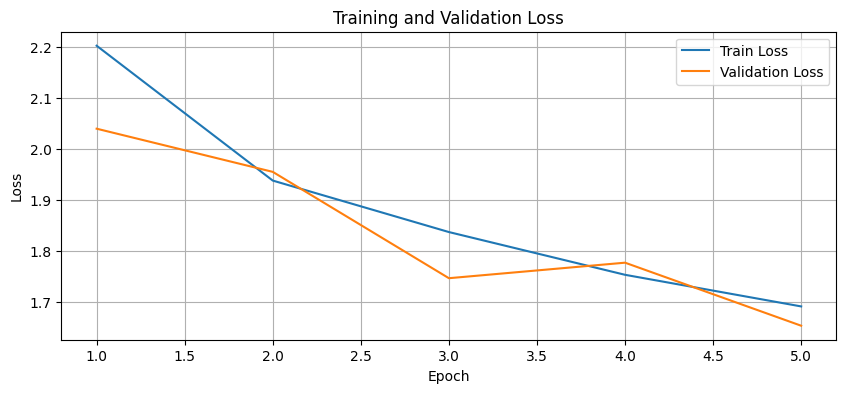

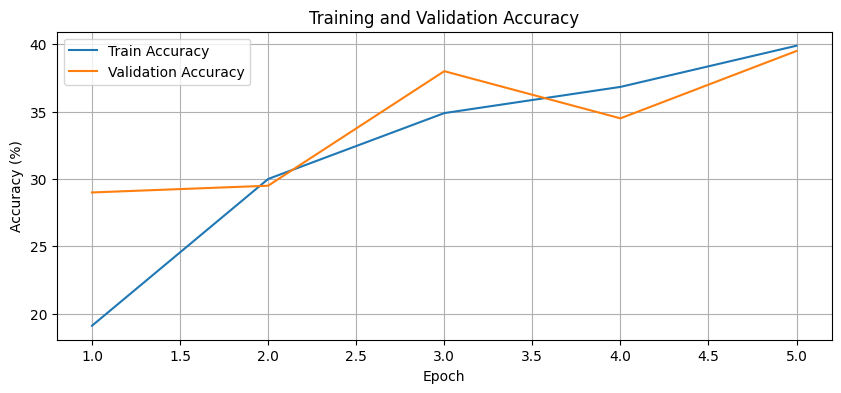

In [127]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

# Plot Loss
plt.figure(figsize=(10, 4))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.plot(epochs, [acc * 100 for acc in train_accuracies], label='Train Accuracy')
plt.plot(epochs, [acc * 100 for acc in valid_accuracies], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Afterwards, we load our the parameters of the model that achieved the best validation loss and then use this to evaluate our model on the test set.

In [128]:
model.load_state_dict(torch.load('tut1-model.pt'))

test_loss, test_acc = evaluate(model, test_iterator, criterion, device)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/125 [00:00<?, ?it/s]

Test Loss: 1.665 | Test Acc: 40.40%


### Examining the Model

Now we've trained our model, there are a few things we can look at. Most of these are simple exploratory analysis, but they can offer some insights into your model.

An important thing to do is check what examples your model gets wrong and ensure that they're reasonable mistakes.

The function below will return the model's predictions over a given dataset. It will return the inputs (image) the outputs (model predictions) and the ground truth labels.

In [129]:
def get_predictions(model, iterator, device):

    model.eval()

    images = []
    labels = []
    probs = []

    with torch.no_grad():

        for (x, y) in iterator:

            x = x.to(device)

            y_pred = model(x)

            y_prob = F.softmax(y_pred, dim=-1)

            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0)
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)

    return images, labels, probs

We can then get these predictions and, by taking the index of the highest predicted probability, get the predicted labels.

In [130]:
images, labels, probs = get_predictions(model, test_iterator, device)

pred_labels = torch.argmax(probs, 1)

Next, for each of our examples, we can check if our predicted label matches our actual label.

In [131]:
corrects = torch.eq(labels, pred_labels)

We can then loop through all of the examples over our model's predictions and store all the examples the model got incorrect into an array.

Then, we sort these incorrect examples by how confident they were, with the most confident being first.

In [132]:
incorrect_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
    if not correct:
        incorrect_examples.append((image, label, prob))

incorrect_examples.sort(reverse=True,
                        key=lambda x: torch.max(x[2], dim=0).values)

We can then plot the incorrectly predicted images along with how confident they were on the actual label and how confident they were at the incorrect label.

In [133]:
def plot_most_incorrect(incorrect, n_images, class_names=None):
    rows = int(np.sqrt(n_images))
    cols = int(np.ceil(n_images / rows))

    fig = plt.figure(figsize=(cols * 1.5, rows * 1.5))
    for i in range(rows * cols):
        ax = fig.add_subplot(rows, cols, i + 1)

        image, true_label, probs = incorrect[i]
        true_prob = probs[true_label].item()
        incorrect_prob, incorrect_label = torch.max(probs, dim=0)
        incorrect_prob = incorrect_prob.item()
        incorrect_label = incorrect_label.item()

        # Prepare image for display
        img = image.permute(1, 2, 0).cpu().numpy()  # (C, H, W) → (H, W, C)
        img = np.clip(img, 0, 1)
        ax.imshow(img)

        # Set title for each subplot
        if class_names:
            title = f'True: {class_names[true_label]} ({true_prob:.2f})\nPred: {class_names[incorrect_label]} ({incorrect_prob:.2f})'
        else:
            title = f'True: {true_label} ({true_prob:.2f})\nPred: {incorrect_label} ({incorrect_prob:.2f})'

        ax.set_title(title, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Below are 25 images that the model classified incorrectly but with high confidence.

These samples are low in resolution, which makes it challenging for the model to perform well. Even for images that appear relatively clear, if you look closely, you can begin to understand why the model made mistakes.

Why is the neural network so confident in these incorrect predictions? The model is trained to use different levels of features—such as colors, edges, and structures—to map images to classes. As a result, when it encounters a new image, it tries to match it to patterns it has seen during training, even if the match is imperfect.

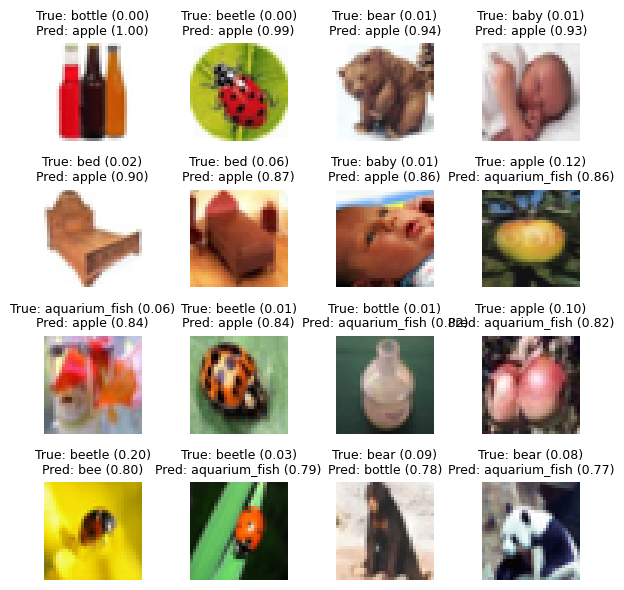

In [134]:
plot_most_incorrect(incorrect_examples, 16, class_names=trainset_full.classes)

### Cross-Validation (CV)

Cross-validation: Splits your existing small_trainset into K folds with stratification (preserves class balance). For each fold it:

1. re-initializes your same MLP and same optimizer
2. trains for a few epochs on the fold’s train split
3. evaluates on the fold’s validation split
4. saves the best epoch per fold by validation loss

Cross-validation gives a more reliable estimate of generalization than a single split and helps you choose a sensible training length (we take the median best epoch observed across folds).

Final retrain & test: After cross-validation, the cell retrains a fresh MLP on the full training subset for that CV-suggested number of epochs and evaluates on your held-out test subset. This lets students feel/see the difference: they compare one final model trained with a data-driven epoch choice versus any arbitrary choice.

No new architectures or transforms are introduced here; it reuses your existing model, loss, optimizer, and dataloaders—just adds cross-validation and a clean end-to-end retrain/test.

Using K-fold validation, we train the same model on K different train/val splits and keep each fold’s best checkpoint. Those K models see slightly different data and learn slightly different decision boundaries; at test time we average their predicted probabilities. This ensemble reduces variance, is more robust to unlucky splits, and often yields a small but consistent accuracy boost—CV tells us what’s reliable; the ensemble makes it more reliable.

In [135]:
# ================================================
# Cross-Validation + Final Retrain & Test (Single Cell)
# Assumes prior cells already defined:
# - small_trainset, small_testset
# - BATCH_SIZE, device, criterion
# - MLP class
# - train(model, iterator, optimizer, criterion, device)
# - evaluate(model, iterator, criterion, device)
# - trainset_full, train_indices_subset (from your earlier subset build)
# ================================================

from sklearn.model_selection import StratifiedKFold
import numpy as np
import torch
import torch.utils.data as data
from torch.utils.data import Subset
import torch.optim as optim
import statistics as stats
import time

# ---------- helpers ----------
def make_loader_from_idx(dataset, idx, batch_size, shuffle):
    sub = Subset(dataset, idx.tolist() if hasattr(idx, "tolist") else list(idx))
    return data.DataLoader(sub, batch_size=batch_size, shuffle=shuffle)

# Labels aligned to small_trainset indices for stratified split
# (uses the same indices list you created earlier: train_indices_subset)
y_small = np.array([trainset_full.targets[i] for i in train_indices_subset])

# infer input/output dims from one batch (uses your current transforms)
sample_x, _ = next(iter(data.DataLoader(small_trainset, batch_size=1)))
INPUT_DIM = sample_x[0].numel()
OUTPUT_DIM = len(set(y_small))  # should be 10 for your selected classes

# ---------- K-fold CV ----------
K = 5                          # change to 3/10 as you wish
EPOCHS_FOLD = 5                # epochs per fold (kept small for speed)
SEED = 9999

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED)
fold_summaries = []

print(f"[INFO] {K}-fold Stratified CV on small_trainset (size={len(small_trainset)})")

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.arange(len(small_trainset)), y_small), start=1):
    print(f"\n========== Fold {fold}/{K} ==========")
    ### add code here
    # Create data loaders for this fold
    train_loader = make_loader_from_idx(small_trainset, tr_idx, BATCH_SIZE, shuffle=True)
    val_loader = make_loader_from_idx(small_trainset, va_idx, BATCH_SIZE, shuffle=False)

    # Initialize fresh model for this fold
    fold_model = MLP(INPUT_DIM, OUTPUT_DIM).to(device)
    fold_optimizer = optim.Adam(fold_model.parameters())

    best_fold = {"val_loss": float("inf"), "val_acc": 0.0, "epoch": -1}

    for ep in range(1, EPOCHS_FOLD + 1):
        # timer
        start_time = time.monotonic()

        tr_loss, tr_acc = train(fold_model, train_loader, fold_optimizer, criterion, device)
        va_loss, va_acc = evaluate(fold_model, val_loader, criterion, device)

        # Track best validation result
        if va_loss < best_fold["val_loss"]:
            best_fold["val_loss"] = va_loss
            best_fold["val_acc"] = va_acc
            best_fold["epoch"] = ep
            best_fold_dict = fold_model.state_dict().copy()

        # timer
        end_time = time.monotonic()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)
        print(f"Epoch {ep}/{EPOCHS_FOLD} | Epoch Time: {epoch_mins}m {epoch_secs}s\n"
              f"Train Loss {tr_loss:.3f} | Train Acc {tr_acc*100:5.2f}%\n"
              f"Val Loss {va_loss:.3f} | Val Acc {va_acc*100:5.2f}%")

    # record
    fold_summaries.append(best_fold)
    torch.save(best_fold_dict, f"mlp_cv_fold{fold}.pt")

# aggregate CV stats
mean_val_loss = stats.mean([s["val_loss"] for s in fold_summaries])
mean_val_acc  = stats.mean([s["val_acc"]  for s in fold_summaries])
std_val_acc   = stats.pstdev([s["val_acc"] for s in fold_summaries]) if K > 1 else 0.0

print("\n========== CV Summary ==========")
for i, s in enumerate(fold_summaries, 1):
    print(f"Fold {i}: best Val Loss {s['val_loss']:.3f}, Val Acc {s['val_acc']*100:5.2f}%")
print(f"\n[CV Aggregate] Val Loss mean {mean_val_loss:.3f} | "
      f"Val Acc mean {mean_val_acc*100:5.2f}% ± {std_val_acc*100:4.2f}%")

# ---------- Final retrain on FULL training subset ----------
# heuristic: use the median of best-epoch counts observed during CV
### add code here
best_epochs = [s["epoch"] for s in fold_summaries]
EPOCHS_FINAL = int(np.median(best_epochs))

print(f"\n[Final Retrain] Training fresh MLP on FULL small_trainset for {EPOCHS_FINAL} epochs...")

### add code here
# Create data (no validation)
final_train_loader = data.DataLoader(small_trainset, batch_size=BATCH_SIZE, shuffle=True)
final_test_loader = data.DataLoader(small_testset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize final model
final_model = MLP(INPUT_DIM, OUTPUT_DIM).to(device)
final_optimizer = optim.Adam(final_model.parameters())

best_final = {"test_loss": float("inf"), "test_acc": 0.0, "epoch": -1}
for ep in range(1, EPOCHS_FINAL + 1):
    ### add code here
    tr_loss, tr_acc = train(final_model, final_train_loader, final_optimizer, criterion, device)
    te_loss, te_acc = evaluate(final_model, final_test_loader, criterion, device)

    # Track best test performance
    if te_loss < best_final["test_loss"]:
        best_final["test_loss"] = te_loss
        best_final["test_acc"] = te_acc
        best_final["epoch"] = ep
        best_final_dict = final_model.state_dict().copy()

    print(f"Epoch {ep:02d} | Train Loss {tr_loss:.3f} Acc {tr_acc*100:5.2f}% | "
          f"Test  Loss {te_loss:.3f} Acc {te_acc*100:5.2f}%")

torch.save(best_final_dict, "mlp_full_retrain.pt")
print(f"\n[Final Result] (best @ epoch {best_final['epoch']:02d}) "
      f"Test Loss {best_final['test_loss']:.3f} | Test Acc {best_final['test_acc']*100:5.2f}%")


[INFO] 5-fold Stratified CV on small_trainset (size=2000)

========== Fold 1/5 ==========


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/5 | Epoch Time: 0m 0s
Train Loss 2.240 | Train Acc 16.44%
Val Loss 2.141 | Val Acc 19.75%


Training:   0%|          | 0/200 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 04 | Train Loss 1.690 Acc 40.30% | Test  Loss 1.773 Acc 36.70%


Training:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 05 | Train Loss 1.628 Acc 41.65% | Test  Loss 1.711 Acc 39.60%

[Final Result] (best @ epoch 05) Test Loss 1.711 | Test Acc 39.60%


### Ensemble Learning
After validation generates checkpoints from multiple set-ups, we keep those best-epoch checkpoints and let them vote. Concretely, for each test image we run all K models, take their softmax probabilities, and average them; the final label is the argmax of that averaged distribution, and the loss is computed against the averaged probability of the true class. This simple scheme (a) reduces variance—idiosyncrasies from any one fold get diluted, (b) improves calibration—confidence is less spiky, and (c) often gives a modest but reliable accuracy lift without changing architecture or data.

Ensembles help most with small, noisy, or unstable settings (like a tiny CIFAR slice + a lightweight MLP), because different folds latch onto different cues; pooling them captures complementary hypotheses and smooths over unlucky splits. The costs are practical: more checkpoints to store and K forward passes per batch at inference, with diminishing returns as models become more similar. Still, since CV already trains those K models, turning them into an ensemble is mostly bookkeeping—and a clean, trustworthy way to squeeze extra performance from the same data.





In [136]:
# ================================================
# Ensemble Evaluation (after CV + Final Retrain)
# - Loads mlp_cv_fold*.pt checkpoints (and mlp_full_retrain.pt if present)
# - Builds a probability-averaging ensemble
# - Reports ensemble Test Loss / Test Acc on small_testset
# Assumes prior cells defined:
#   small_testset, BATCH_SIZE, device, criterion, MLP, INPUT_DIM, OUTPUT_DIM
# ================================================

import glob, re, os
import torch
import torch.nn.functional as F
import torch.utils.data as data

# --- test loader (same as before) ---
test_loader_full = data.DataLoader(small_testset, batch_size=BATCH_SIZE, shuffle=False)

# --- discover fold checkpoints ---
ckpt_paths = sorted(
    glob.glob("mlp_cv_fold*.pt"),
    key=lambda p: int(re.search(r"mlp_cv_fold(\d+)\.pt", p).group(1)) if re.search(r"mlp_cv_fold(\d+)\.pt", p) else 1e9
)

# (optional) also include the final retrained model if it exists
if os.path.exists("mlp_full_retrain.pt"):
    ckpt_paths.append("mlp_full_retrain.pt")

if not ckpt_paths:
    raise RuntimeError("No checkpoints found. Run the CV cell first to create mlp_cv_fold*.pt checkpoints.")

print(f"[Ensemble] Found {len(ckpt_paths)} checkpoints:")
for p in ckpt_paths:
    print(" -", p)

# --- load models ---
models = []
for p in ckpt_paths:
    m = MLP(INPUT_DIM, OUTPUT_DIM).to(device)
    m.load_state_dict(torch.load(p, map_location=device))
    m.eval()
    models.append(m)

# --- evaluate ensemble: average probabilities across models ---
def evaluate_ensemble(models, loader, device):
    ### add function here
    total_loss = 0.0
    total_acc = 0.0

    with torch.no_grad():

        for (x, y) in tqdm(loader, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            all_probs = []
            for model in models:
                model.eval()

                y_pred = model(x)
                prob = F.softmax(y_pred, dim=1)  # Convert logits to probabilities
                all_probs.append(prob)

            avg_probs = torch.stack(all_probs).mean(dim=0)
            avg_logits = torch.log(avg_probs + 1e-10)  # Add small epsilon to avoid log(0)

            loss = criterion(avg_logits, y)

            acc = calculate_accuracy(avg_logits, y)

            total_loss += loss.item()
            total_acc += acc.item()

    return total_loss / len(loader), total_acc / len(loader)

ens_loss, ens_acc = evaluate_ensemble(models, test_loader_full, device)

print("\n========== Ensemble on Test Set ==========")
print(f"Models ensembled: {len(models)}")
print(f"Test Loss (ensemble): {ens_loss:.3f}")
print(f"Test Acc  (ensemble): {ens_acc*100:5.2f}%")

[Ensemble] Found 6 checkpoints:
 - mlp_cv_fold1.pt
 - mlp_cv_fold2.pt
 - mlp_cv_fold3.pt
 - mlp_cv_fold4.pt
 - mlp_cv_fold5.pt
 - mlp_full_retrain.pt


Evaluating:   0%|          | 0/125 [00:00<?, ?it/s]


========== Ensemble on Test Set ==========
Models ensembled: 6
Test Loss (ensemble): 1.634
Test Acc  (ensemble): 44.60%


### Final Results Comparisons

In [137]:
# ================================================
# Print-only Comparison (no retraining / no re-eval)
# Expects you've ALREADY computed these somewhere:
#   - Baseline test acc:        test_acc            or baseline_test_acc
#   - CV final test acc:        best_final['test_acc']   (from CV-retrain cell)
#   - Ensemble test acc:        ens_acc                  (from ensemble cell)
# This cell just reads existing variables and prints them.
# ================================================

def _get_scalar(name_chain):
    for name in name_chain:
        try:
            return float(eval(name))
        except Exception:
            pass
    return None

## add code here
baseline_acc = _get_scalar(["baseline_test_acc", "test_acc"])
cv_final_acc = _get_scalar(["best_final['test_acc']"])
ens_acc      = _get_scalar(["ens_acc"])

print("\n================ Test Accuracy (No Recompute) ================")
## add code here
print(f"Baseline (no CV)     | Test Acc: {baseline_acc*100:5.2f}%")
print(f"CV-guided Final      | Test Acc: {cv_final_acc*100:5.2f}%")
print(f"Ensemble             | Test Acc: {ens_acc*100:5.2f}%")
print(f"Δ vs Baseline → CV-guided Final: {(cv_final_acc - baseline_acc)*100:5.2f}%")
print(f"Δ vs Baseline → Ensemble       : {(ens_acc - baseline_acc)*100:5.2f}%")

print("==============================================================")



================ Test Accuracy (No Recompute) ================
Baseline (no CV)     | Test Acc: 40.40%
CV-guided Final      | Test Acc: 39.60%
Ensemble             | Test Acc: 44.60%
Δ vs Baseline → CV-guided Final: -0.80%
Δ vs Baseline → Ensemble       :  4.20%


# 🛠️ TO DO

## 📦 Submission Instructions

Please submit **both** of the following files:

- 📄 **Report (PDF)**  
  Your PDF should include:
  - Answers to all conceptual questions
  - Training and validation metrics (loss/accuracy) for each setting
  - If you made **any code modifications** during experiments (e.g., changing dropout rate, adding regularization, etc.), please **include screenshots** of the modified code in the PDF.

- 🧑‍💻 **Code File (`.ipynb`)**  
  Submit only your **final version** of the notebook.  
  Make sure it runs without error, includes necessary comments, and contains all relevant output.

⚠️ If intermediate changes are not documented in your PDF, full credit may not be given!

---

### 🗂 File Naming Convention

To help us clearly identify the owner of each submission, please **follow this naming format**:

- Notebook file: `your_name_DL_HW#.ipynb`  
- Report file: `your_name_DL_HW#.pdf`

> Replace `your_name` with your full name and `#` with the assignment number.

✅ **Example**:  
- `Shengan_Wang_DL_HW1.ipynb`  
- `Shengan_Wang_DL_HW1.pdf`

(You may use either your English name or your Chinese name.)


## 📝 Your assignments

This assignment will walk you through a simple training pipeline and guide you to analyze overfitting and possible solutions.

(Note: We’d like to see your own answers — even if they’re a bit imperfect — rather than something that just feels AI-generated.)


### 1. Record Baseline Performance and the concepts about overfitting (30%)
(1) Run the provided example and first train for 5 epochs, recording the training and validation loss/accuracy. (5%)

(2) Then extend the training to 30 epochs, re-run the training **from scratch**,, and again record the loss and accuracy. (5%)

(3) ✏️ What is **overfitting and underfitting** in deep learning? Please describe it in your own words. (10%)

(4) Compare the graphs from epoch = 5 and epoch = 30. Do these results indicate underfitting or overfitting? Explain why. (10%)

---
### 2. Add Dropout (30%)

(1) ✏️ **What is Dropout?**  Please briefly explain what dropout does in a neural network in your own words. (10%)

(2) Add a **Dropout layer with `p = 0.5`** after the hidden layer, and then train the model again for **30 epochs**, record the new **loss and accuracy**. (10%)

> 💡 **Hint – How to add Dropout using `F.dropout`**  
> In your `forward()` function, after the ReLU activation, insert a dropout operation like this:
>
> ```python
> x = F.dropout(x, p=0.5, training=self.training)
> ```
>
> 🔍 `training=self.training` ensures that dropout is only applied during training, and automatically disabled when calling `model.eval()` for testing.

(3) 🔍 *Did dropout help reduce or fix the overfitting issue? Why do you think so?* (10%)


---

### 3. Add cross-validation (20%)

(1) Implement K-fold stratified cross-validation for K = 5 on your existing small_trainset in Cross-Validation code block, and then report: a table of per-fold validation loss/accuracy, plus mean ± std across folds. (5%)
  - For each fold:
    1. Re-initialize the same MLP and optimizer
    2. Train for a few epochs on the fold’s train split
    3. Evaluate on the fold’s validation split
    4. Save the best epoch by validation loss

(2) Choose training length: take the median of best epochs across folds, and  retrain once on the full training subset for that CV-suggested number of epochs and evaluate on the (unchanged) test set. (5%)

(3) 🔍 How different are the per-fold results? What does the std tell you about variance/instability of training on a tiny dataset? (10%)

---


### 4. Add ensemble learning (20%)
(1) Build an ensemble using the best checkpoint from each fold (optionally including your final retrained model), and at test time average their softmax probabilities across models, then predict via the argmax of the averaged distribution, and then evaluate the ensemble on the same fixed test set as before. (10%)

(2) Compare three results side-by-side by including a concise table showing their Test Accuracy and plus difference Δ vs Baseline, did the ensemble improve test accuracy compared to the best single model?(5%):
  - Baseline (no CV)
  - CV-guided Final (single model retrained with CV-informed epochs)
  - Ensemble (probability average of fold models)

(3) 🧠 Why can averaging across folds reduce variance and produce more stable predictions on small data? Briefly discuss trade-offs (extra storage/compute, diminishing returns).(5%)